<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Used_Car_Price_Prediction_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used Car Price Prediction Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d vrajesh0sharma7/used-car-price-prediction

# Unziping the downloaded file
!unzip used-car-price-prediction.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/vrajesh0sharma7/used-car-price-prediction
License(s): CC0-1.0
used-car-price-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  used-car-price-prediction.zip
replace Used_Car_Price_Prediction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Used_Car_Price_Prediction.csv  


In [4]:
df = pd.read_csv('Used_Car_Price_Prediction.csv')
df.head(11)

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
5,maruti alto k10,2018,petrol,23534,335299,noida,1055,hatchback,NaN,vxi (o) amt,...,1,343212,439056.0,great,2021-04-13T05:55:16.99,True,7788,50295,False,False
6,maruti ritz,2012,diesel,41213,281999,noida,909,hatchback,manual,vdi,...,1,201200,NaN,great,2020-12-29T07:26:25.321,True,6550,42300,False,False
7,hyundai i20,2012,petrol,38328,321499,noida,2760,hatchback,manual,asta 1.2,...,3,319200,410764.0,great,2021-02-25T15:47:30.3,True,7468,48225,False,False
8,hyundai elite i20,2014,diesel,56402,456199,noida,2475,hatchback,manual,magna 1.4 crdi,...,1,452023,566123.0,great,2021-03-13T11:57:25.71,True,10596,68430,False,False
9,renault kwid,2018,petrol,32703,281299,noida,2497,hatchback,manual,rxl,...,1,264597,344127.0,great,2021-03-20T06:52:56.488,True,6534,42195,False,False


In [5]:
df.tail(11)

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
7389,maruti wagon r 1.0,2012,petrol,40091,310599,mumbai,245,hatchback,manual,vxi,...,1,286671,NaN,great,2021-03-31T11:33:32.622,True,7214,46590,False,False
7390,maruti zen estilo,2010,petrol,40225,213599,bengaluru,1453,hatchback,manual,lxi,...,2,215023,NaN,great,2020-12-15T14:34:32.735,True,4961,32040,False,False
7391,maruti alto 800,2015,petrol,32821,232199,ahmedabad,1733,hatchback,manual,vxi,...,1,234575,294470.0,great,2021-04-06T11:33:24.506,True,5393,34830,False,False
7392,maruti alto k10,2010,petrol,40666,189699,new delhi,1327,hatchback,manual,vxi,...,1,174955,234300.0,great,2021-02-19T05:23:22.199,True,4406,28455,False,False
7393,volkswagen jetta,2012,petrol,88973,448699,new delhi,1171,sedan,manual,trendline 1.4 tsi mt,...,2,450466,564246.0,great,2021-03-20T09:07:40.447,True,10422,67305,False,False
7394,maruti 800,2002,petrol & lpg,77323,35000,ahmedabad,492,hatchback,manual,ac,...,2,0,NaN,overpriced,2019-12-31T16:07:01.563,False,813,5250,False,False
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,...,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,...,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,...,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,...,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False


In [6]:
df.shape

(7400, 29)

In [7]:
df.columns

Index(['car_name', 'yr_mfr', 'fuel_type', 'kms_run', 'sale_price', 'city',
       'times_viewed', 'body_type', 'transmission', 'variant', 'assured_buy',
       'registered_city', 'registered_state', 'is_hot', 'rto', 'source',
       'make', 'model', 'car_availability', 'total_owners', 'broker_quote',
       'original_price', 'car_rating', 'ad_created_on', 'fitness_certificate',
       'emi_starts_from', 'booking_down_pymnt', 'reserved', 'warranty_avail'],
      dtype='object')

# Selecting some columns for analysis

In [8]:
# Select a subset of columns for analysis
selected_columns = ['car_name', 'yr_mfr', 'fuel_type', 'sale_price','total_owners','original_price','car_rating','warranty_avail']
df_selected = df[selected_columns]

df_selected.head(11)

,car_name,yr_mfr,fuel_type,sale_price,total_owners,original_price,car_rating,warranty_avail
0,maruti swift,2015,petrol,386399,2,404177.0,great,False
1,maruti alto 800,2016,petrol,265499,1,354313.0,great,False
2,hyundai grand i10,2017,petrol,477699,1,NaN,great,False
3,maruti swift,2013,diesel,307999,1,374326.0,great,False
4,hyundai grand i10,2015,petrol,361499,1,367216.0,great,False
5,maruti alto k10,2018,petrol,335299,1,439056.0,great,False
6,maruti ritz,2012,diesel,281999,1,NaN,great,False
7,hyundai i20,2012,petrol,321499,3,410764.0,great,False
8,hyundai elite i20,2014,diesel,456199,1,566123.0,great,False
9,renault kwid,2018,petrol,281299,1,344127.0,great,False


In [9]:
df_selected.shape

(7400, 8)

In [10]:
df_selected.columns

Index(['car_name', 'yr_mfr', 'fuel_type', 'sale_price', 'total_owners',
       'original_price', 'car_rating', 'warranty_avail'],
      dtype='object')

In [11]:
df_selected.dtypes

,0
car_name,object
yr_mfr,int64
fuel_type,object
sale_price,int64
total_owners,int64
original_price,float64
car_rating,object
warranty_avail,bool


In [12]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   car_name        7400 non-null   object 
 1   yr_mfr          7400 non-null   int64  
 2   fuel_type       7400 non-null   object 
 3   sale_price      7400 non-null   int64  
 4   total_owners    7400 non-null   int64  
 5   original_price  4120 non-null   float64
 6   car_rating      7391 non-null   object 
 7   warranty_avail  7400 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(3)
memory usage: 412.0+ KB


In [13]:
df_selected.describe(include = 'all')

,car_name,yr_mfr,fuel_type,sale_price,total_owners,original_price,car_rating,warranty_avail
count,7400,7400.000000,7400,7.400000e+03,7400.000000,4.120000e+03,7391,7400
unique,185,NaN,5,NaN,NaN,NaN,4,2
top,maruti swift,NaN,petrol,NaN,NaN,NaN,great,False
freq,535,NaN,4659,NaN,NaN,NaN,6299,7190
mean,NaN,2013.885676,NaN,4.548892e+05,1.327297,5.510351e+05,NaN,NaN
std,NaN,3.087613,NaN,2.827023e+05,0.579798,3.119887e+05,NaN,NaN
min,NaN,1996.000000,NaN,0.000000e+00,1.000000,9.689900e+04,NaN,NaN
25%,NaN,2012.000000,NaN,2.811740e+05,1.000000,3.414930e+05,NaN,NaN
50%,NaN,2014.000000,NaN,3.824490e+05,1.000000,4.674800e+05,NaN,NaN
75%,NaN,2016.000000,NaN,5.401490e+05,2.000000,6.675258e+05,NaN,NaN


In [14]:
df_selected.isnull().sum()

,0
car_name,0
yr_mfr,0
fuel_type,0
sale_price,0
total_owners,0
original_price,3280
car_rating,9
warranty_avail,0


# Handling Missing Values

In [15]:
df_cleaned = df_selected.dropna(subset=['original_price'])
display(df_cleaned.shape)

df_cleaned.isnull().sum()

(4120, 8)

,0
car_name,0
yr_mfr,0
fuel_type,0
sale_price,0
total_owners,0
original_price,0
car_rating,0
warranty_avail,0


In [16]:
df_selected.duplicated().sum()

np.int64(5)

# Univariate Analysis

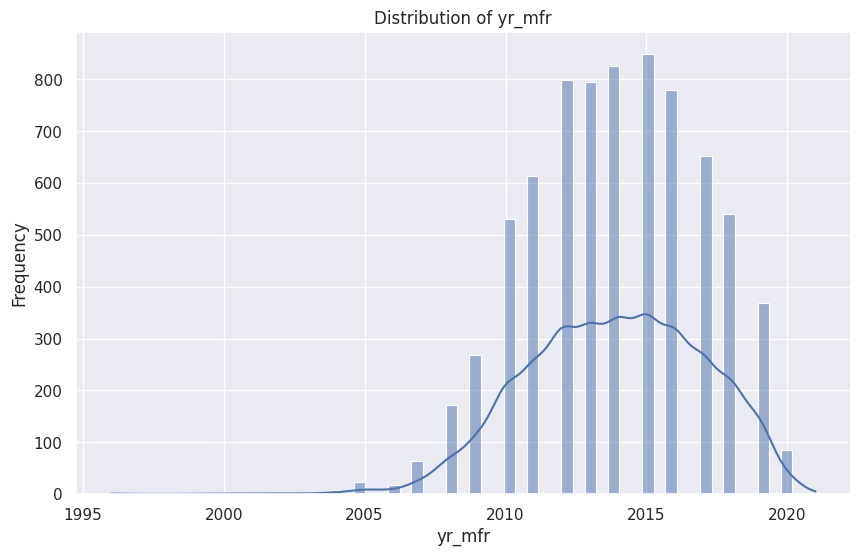

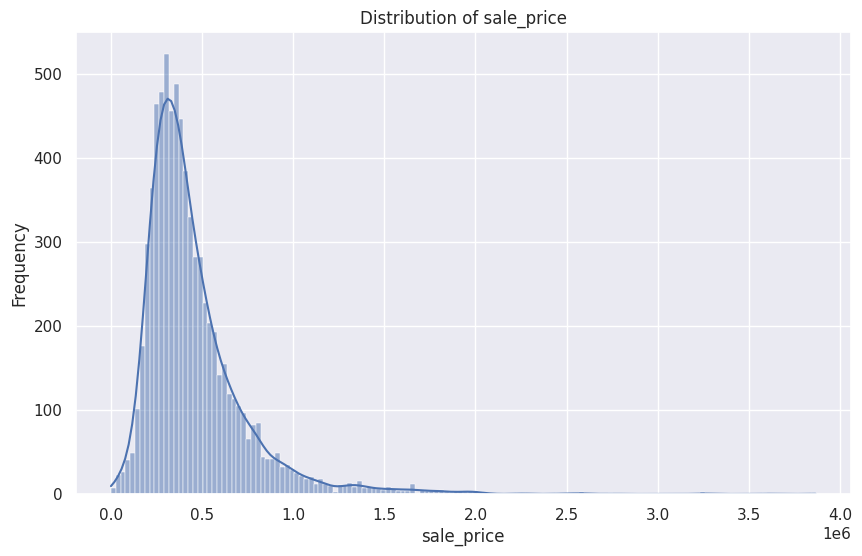

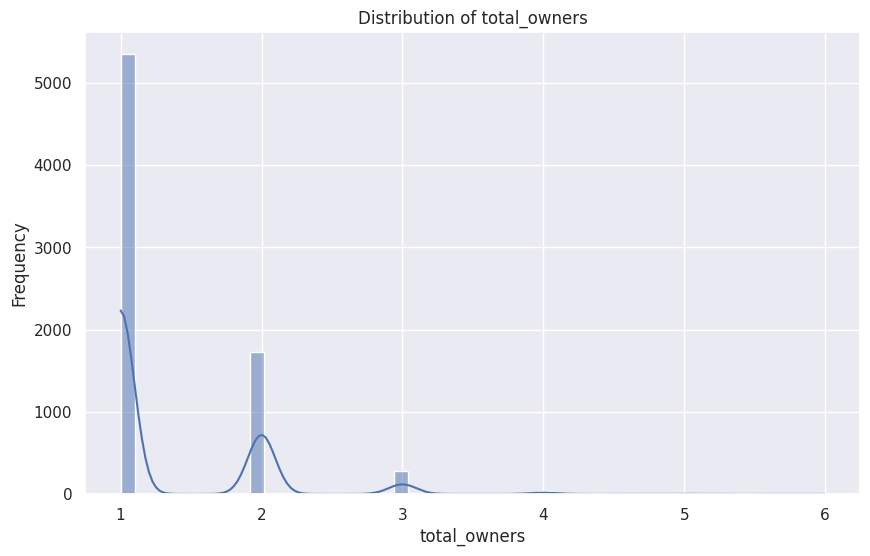

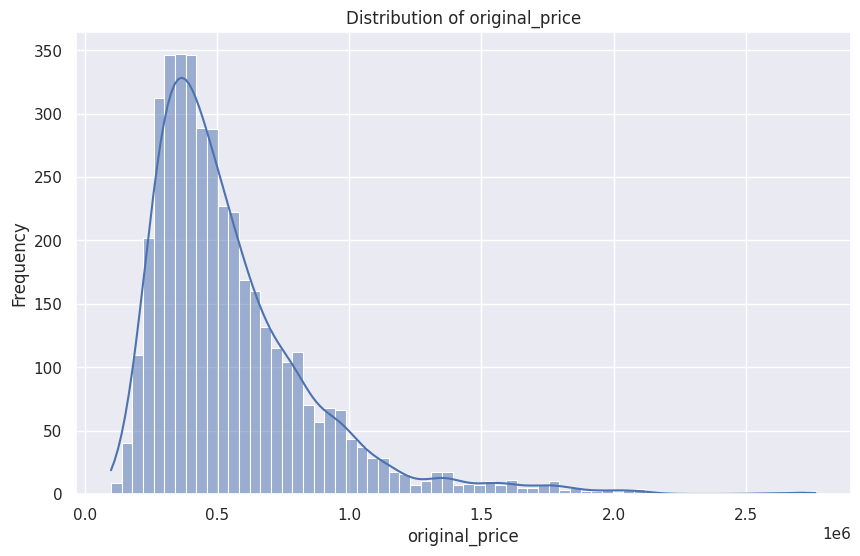

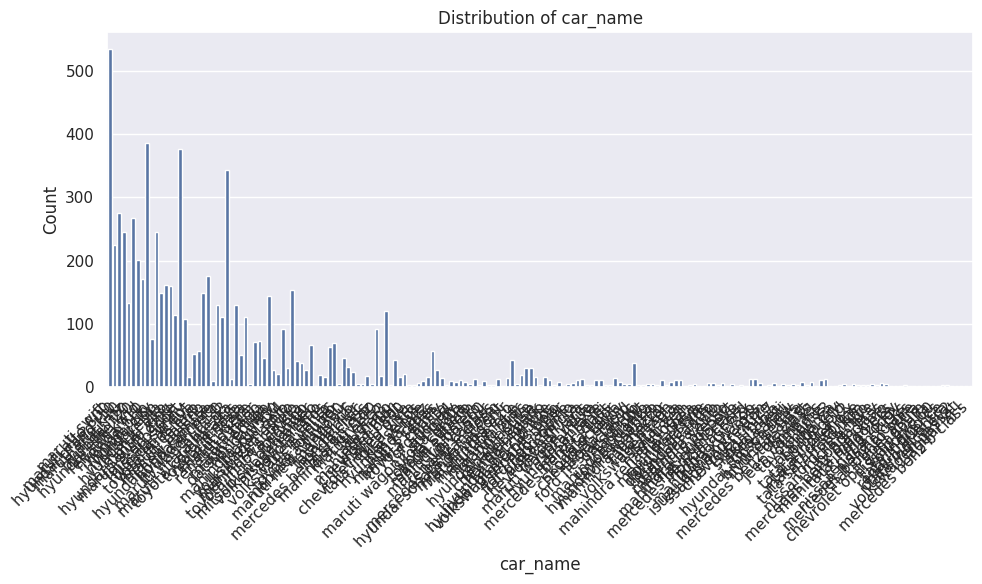

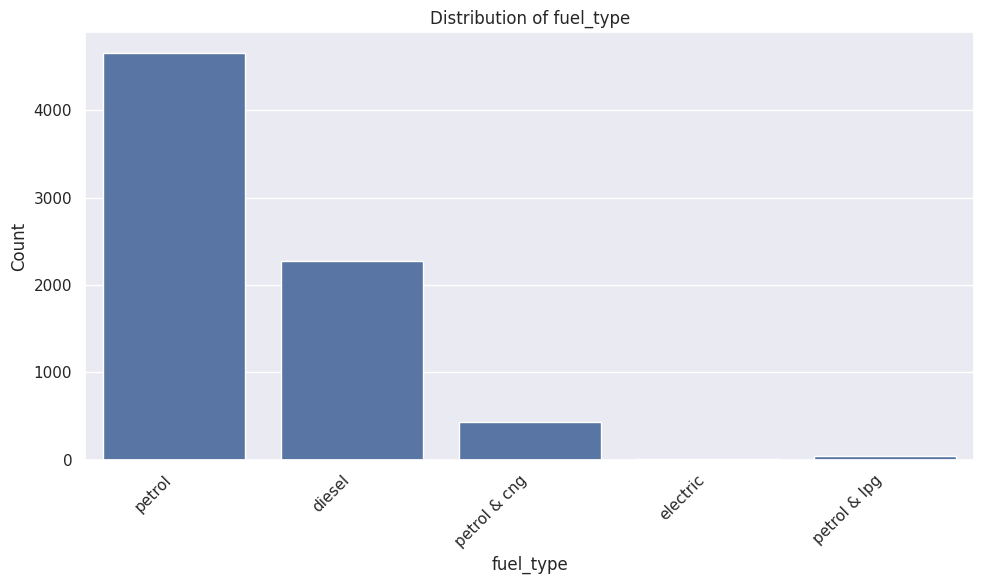

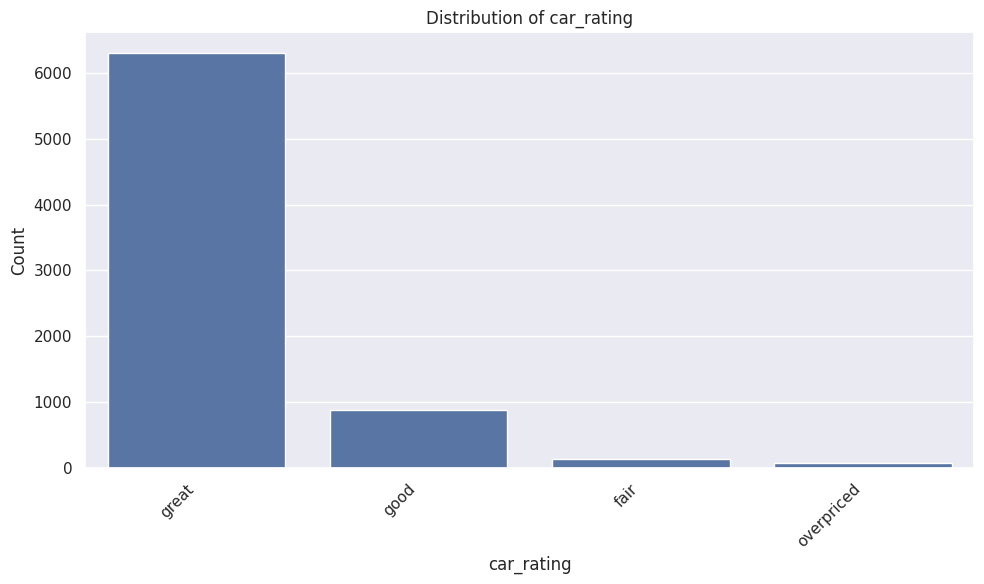

Value counts for car_name:
car_name
maruti swift             535
hyundai i10              386
maruti swift dzire       377
maruti wagon r 1.0       344
hyundai grand i10        275
                        ... 
chevrolet optra            1
tata indica ev2            1
volkswagen passat          1
jaguar xj l                1
mercedes benz b class      1
Name: count, Length: 185, dtype: int64

Value counts for fuel_type:
fuel_type
petrol          4659
diesel          2269
petrol & cng     425
petrol & lpg      41
electric           6
Name: count, dtype: int64

Value counts for car_rating:
car_rating
great         6299
good           881
fair           131
overpriced      80
Name: count, dtype: int64



In [17]:
# Get a list of numerical columns
numerical_cols = df_selected.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df_selected, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df_selected.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_selected, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df_selected[col].value_counts()}\n")

# Bivariate Analysis

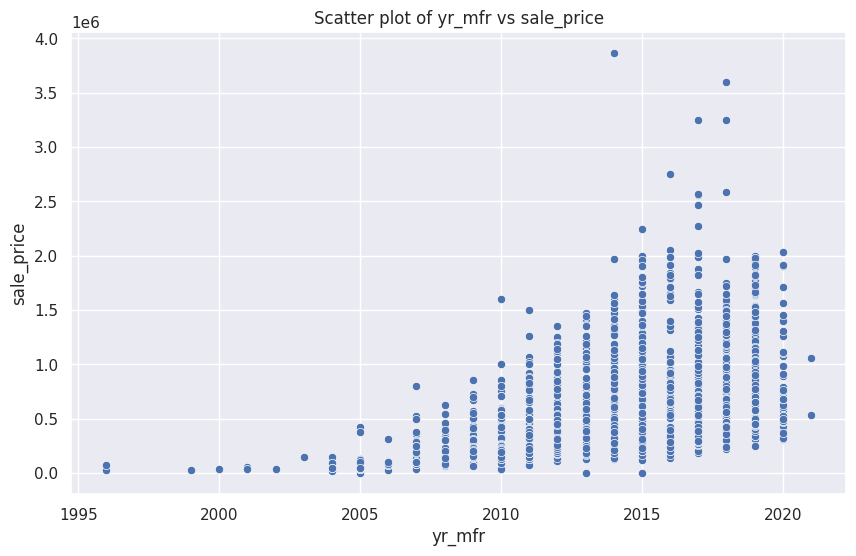

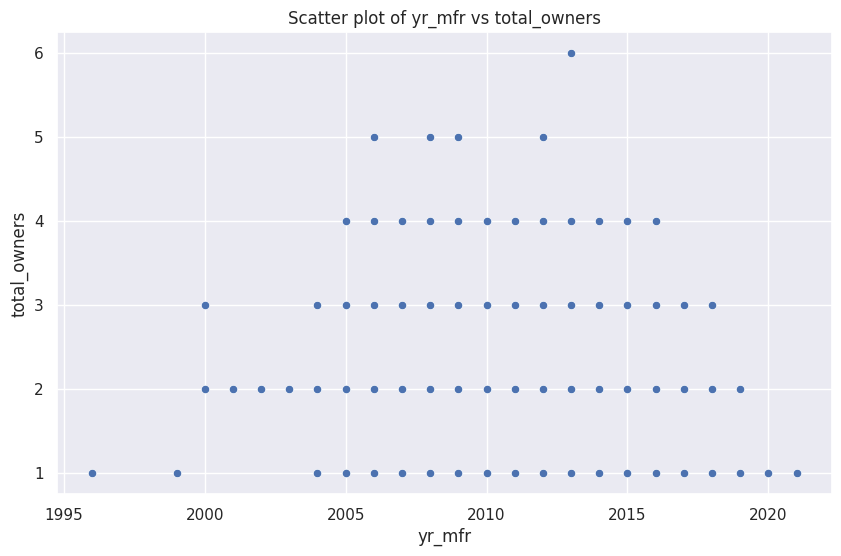

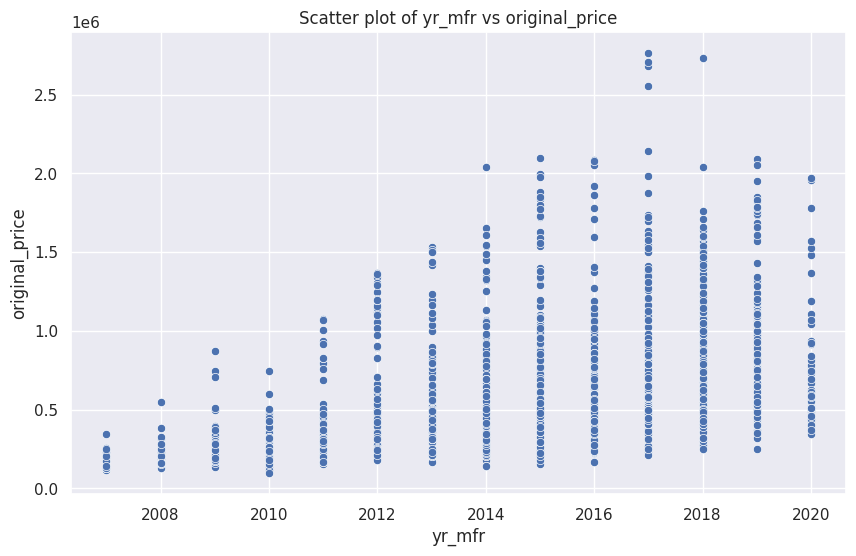

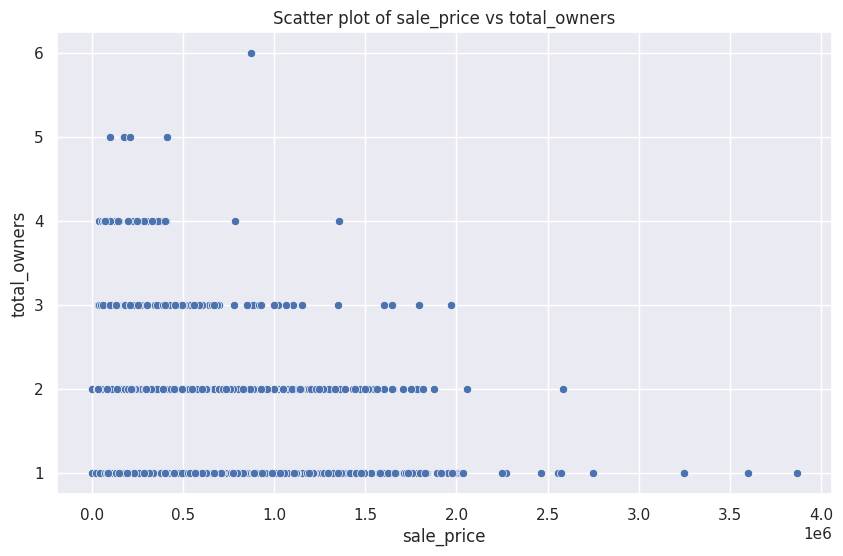

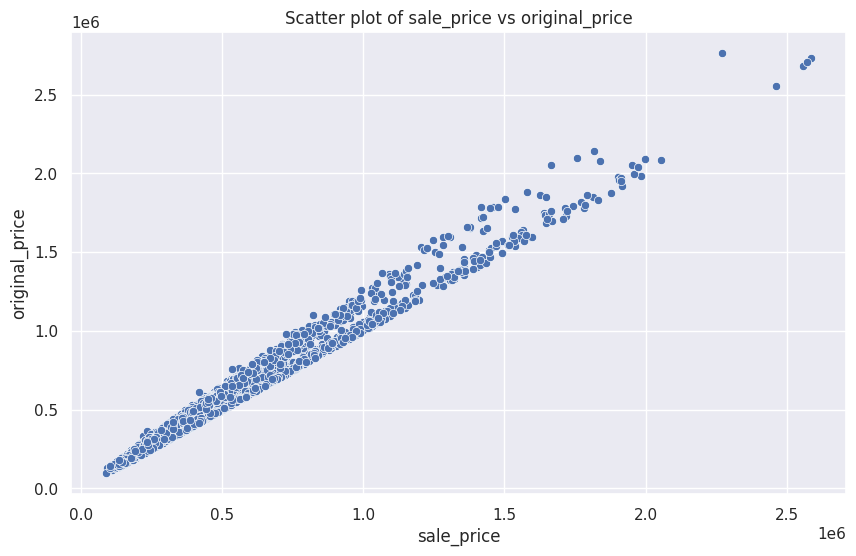

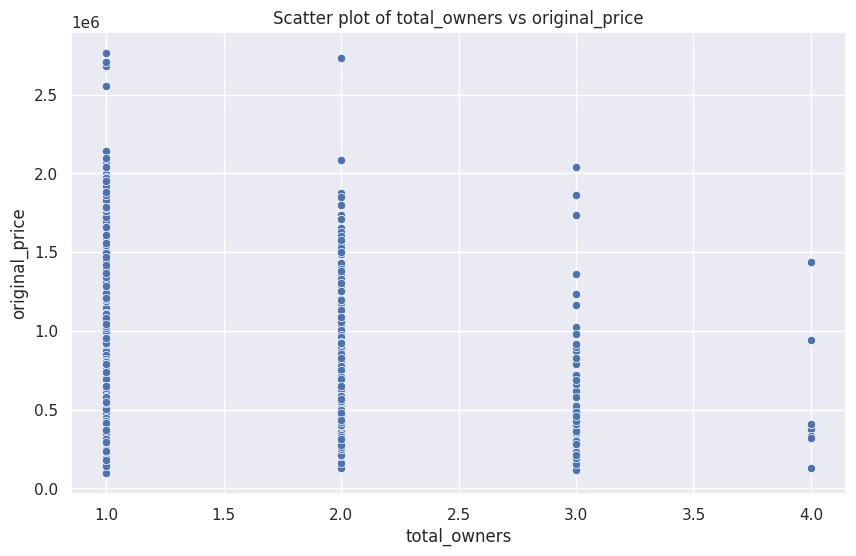

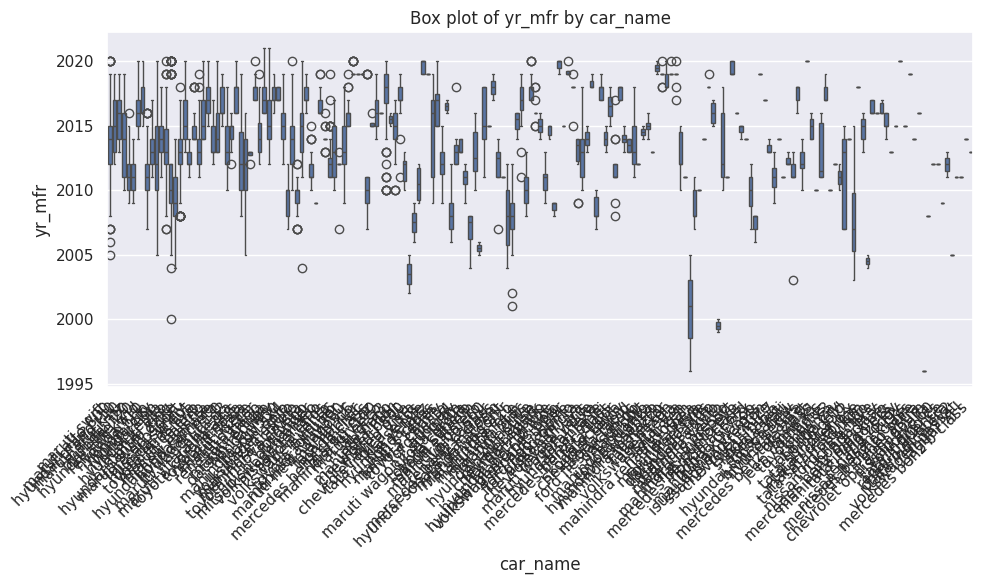

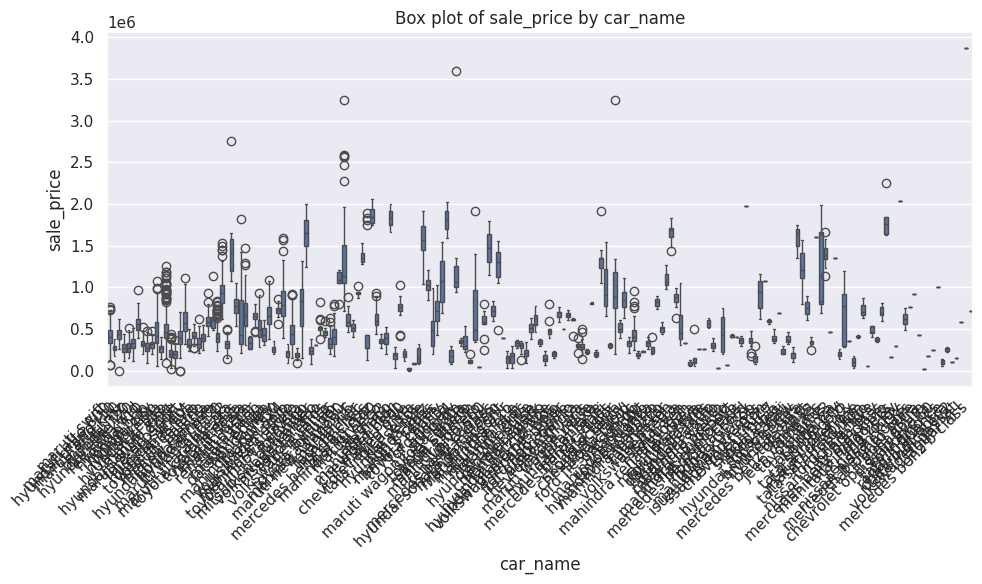

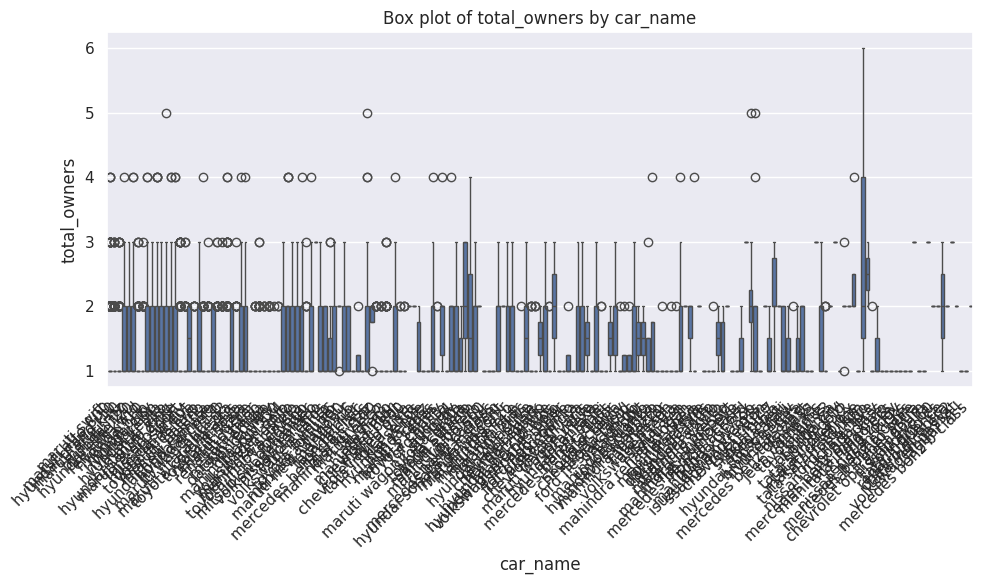

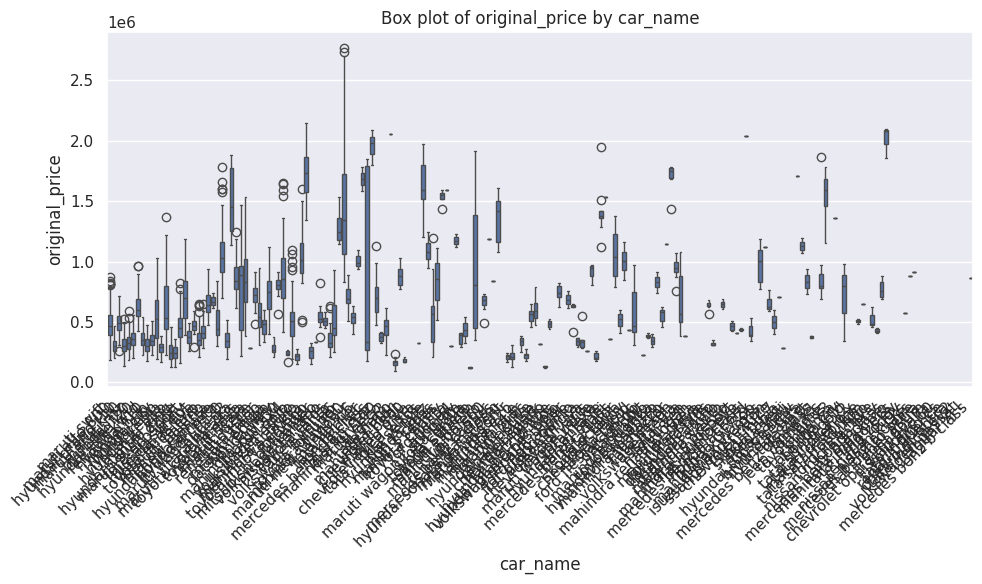

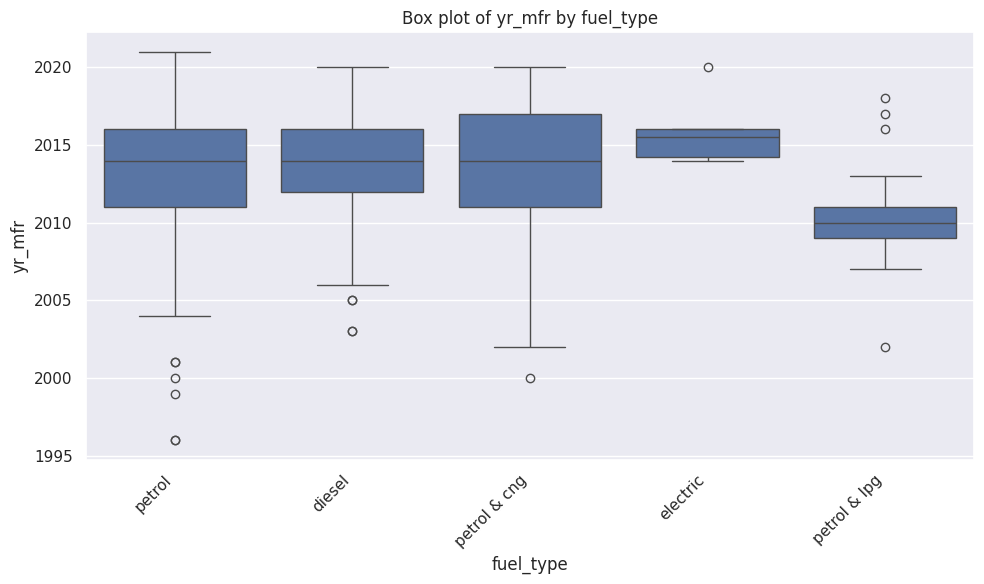

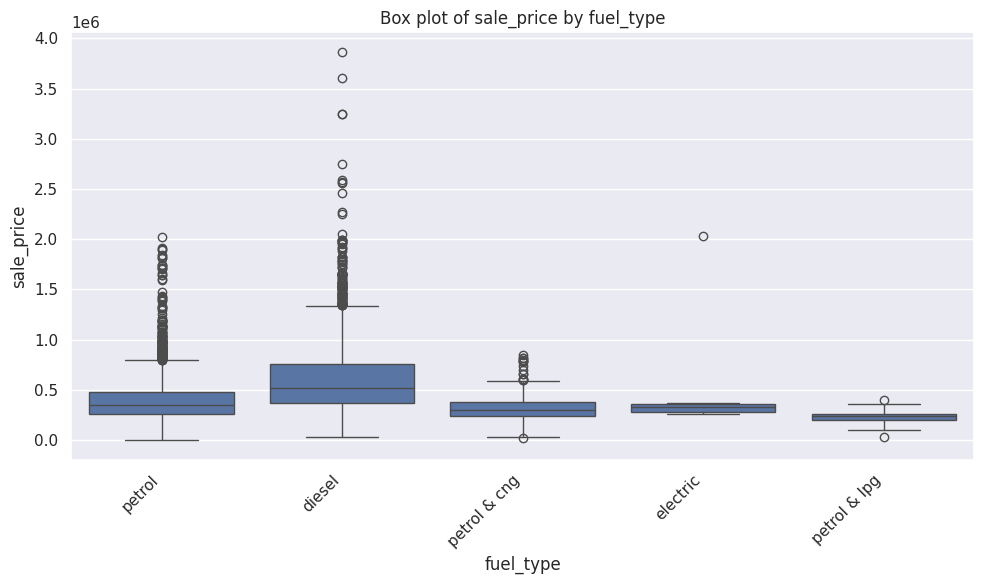

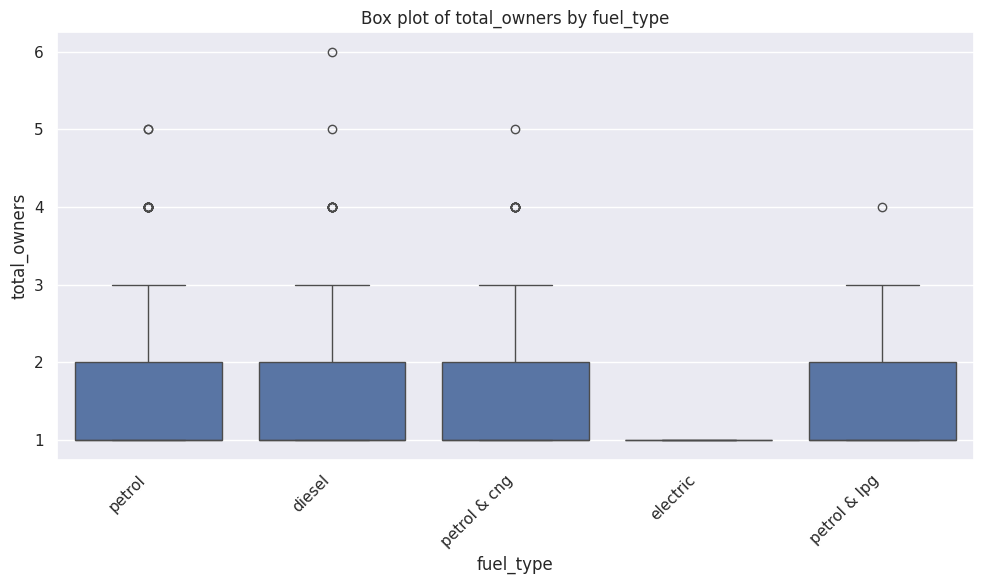

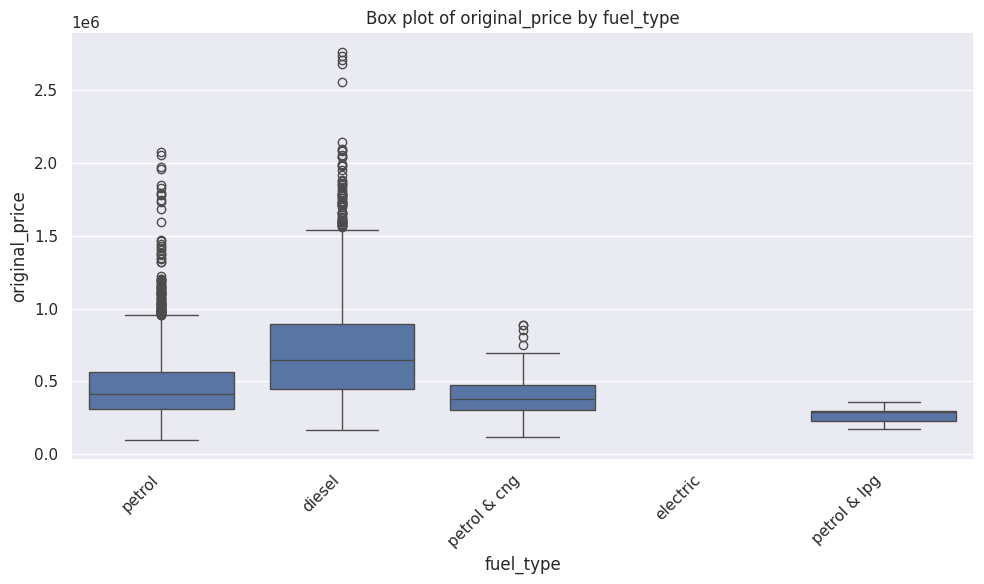

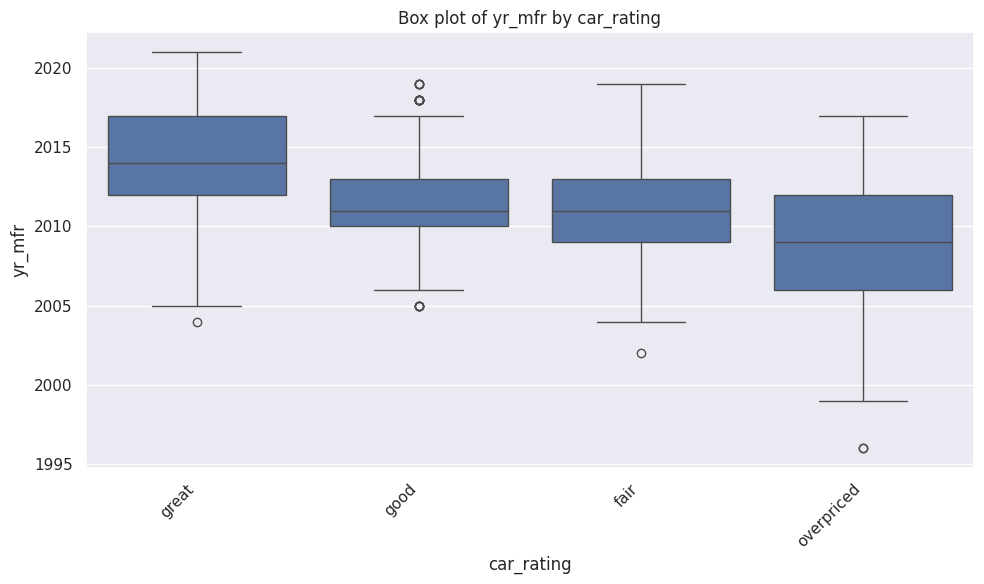

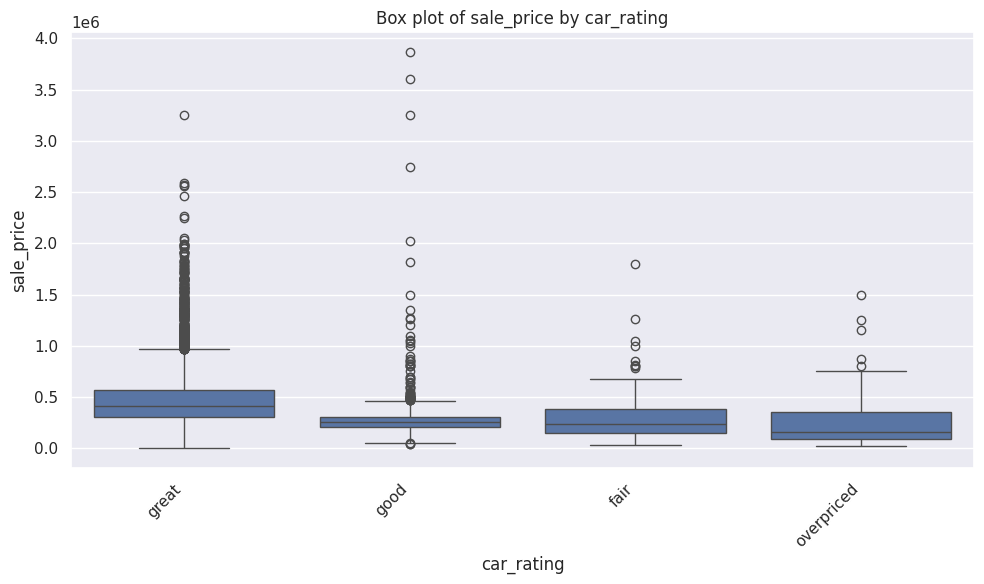

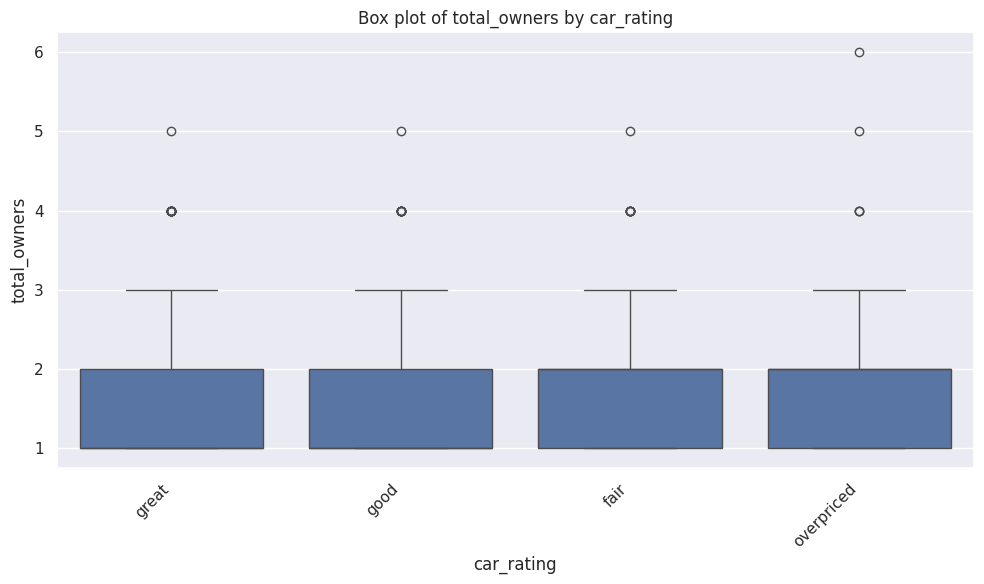

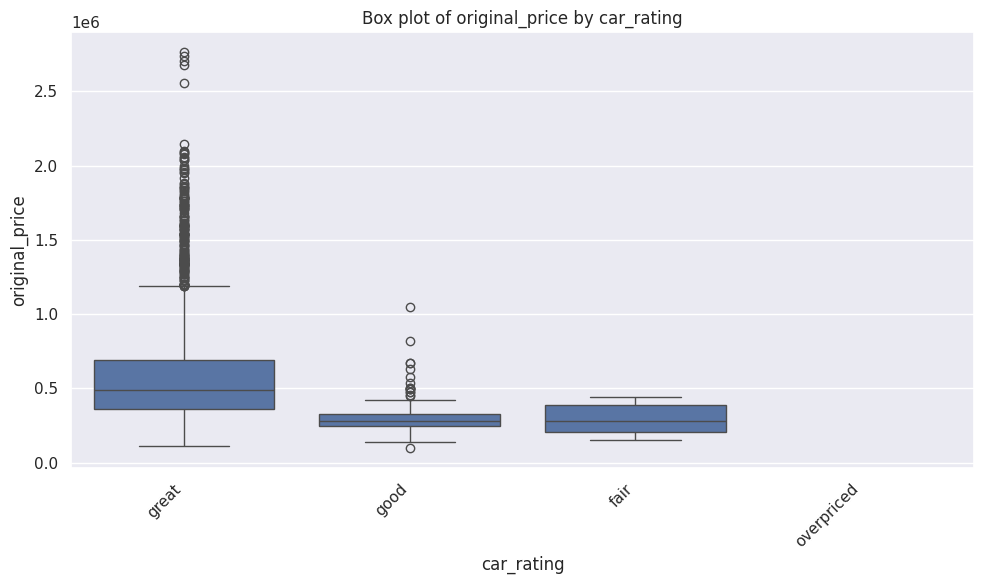

In [18]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df_selected.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df_selected, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df_selected.select_dtypes(include='object').columns.tolist()
numerical_cols = df_selected.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data= df_selected, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

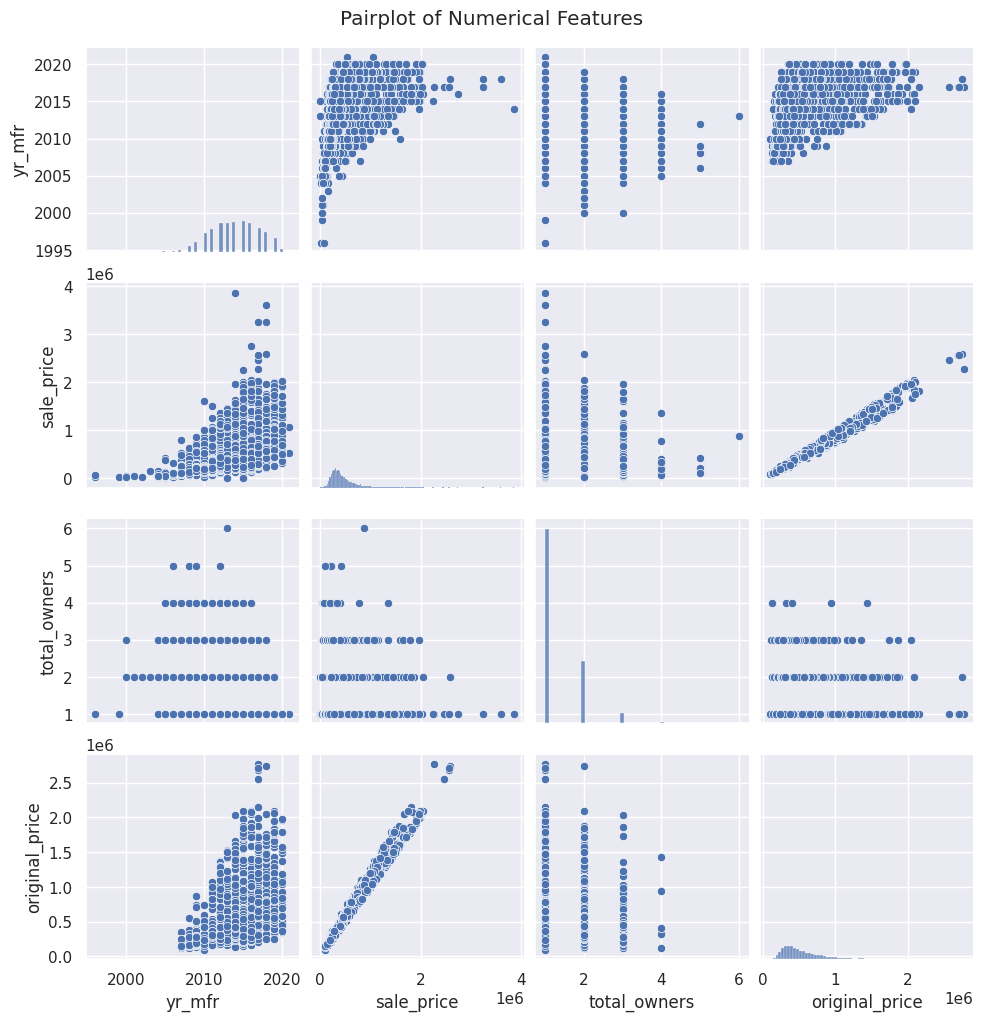

In [19]:
sns.pairplot(df_selected.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

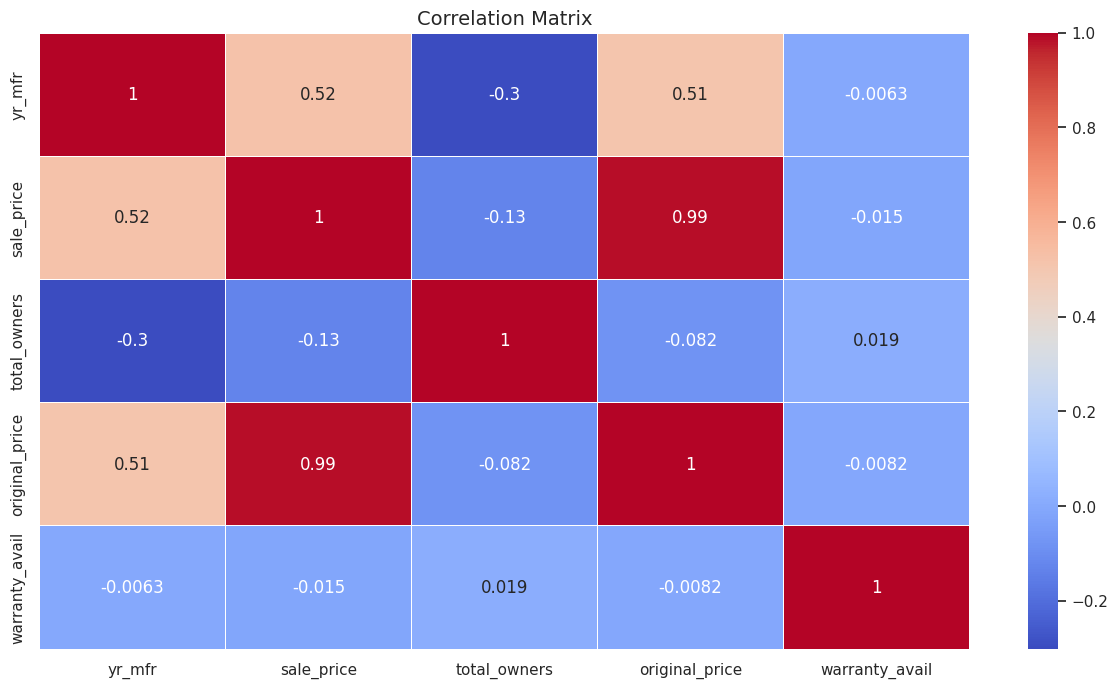

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_selected.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you